# RAGRoute — arXiv 확장 실험 노트북

**코퍼스**: arXiv 논문 초록 500K (`scientific_papers` / HuggingFace)  
**평가**: MMLU STEM 12과목 (physics / CS / math / chemistry / EE / astronomy)

**실행 전 준비사항**
- 런타임: GPU (A100 권장)
- Colab Secrets에 `HF_TOKEN` 저장
- Cell 1의 `REPO_URL`을 본인 repo URL로 수정

### 실행 체크리스트
- [ ] **Cell 1** `cell-setup` — 환경 설정 및 Drive 연결
- [ ] **Cell 2** `cell-arxiv-embed` — arXiv 초록 500K 다운로드 + BGE 인코딩 + k-means (~60~90분)
- [ ] **Cell 3** `cell-arxiv-index` — normalize_L2 + IndexFlatIP 인덱스 빌드 (~5분)
- [ ] **Cell 4** `cell-arxiv-traindata` — 라벨 생성 (LABEL_K=15, IP 내림차순, test=60%) (~10분)
- [ ] **Cell 5** `cell-arxiv-train` — 라우터 학습 150 epoch, best=val_f1 (~15분)
- [ ] **Cell 6** `cell-arxiv-eval-cls` — 분류 성능 확인 (Acc / Recall / F1 / AUC)
- [ ] **Cell 7** `cell-arxiv-reduction` — Query Reduction 분석
- [ ] **Cell 8** `cell-pip-vllm` — vllm 설치
- [ ] **Cell 9** `cell-arxiv-eval` — vLLM 기동 + no_rag / rag_all / ragroute 평가 (~30~60분)
- [ ] **Cell 10** `cell-arxiv-results` — 결과 출력 및 wikipedia와 비교

> Drive `ragroute/embeddings/arxiv/`에 자동 저장 → 런타임 재시작 후 완료된 단계부터 재개 가능

In [ ]:
import os, sys, shutil, subprocess, torch
from google.colab import drive, userdata

# ⚠️ 여기만 수정
REPO_URL = 'https://github.com/ByoungjaeMin/ragroute_recreation.git'

assert torch.cuda.is_available(), 'GPU 없음: 런타임 > 런타임 유형 변경'
print(f'GPU: {torch.cuda.get_device_name(0)}')

drive.mount('/content/drive')
DRIVE_ROOT = '/content/drive/MyDrive/ragroute'

REPO_PATH = '/content/ragroute_recreation'
if not os.path.isdir(REPO_PATH):
    subprocess.run(['git', 'clone', REPO_URL, REPO_PATH], check=True)
else:
    subprocess.run(['git', '-C', REPO_PATH, 'pull', '--ff-only'])
os.chdir(REPO_PATH)
sys.path.insert(0, REPO_PATH)

subprocess.run(['pip', 'install', '-q', '-r', 'requirements.txt'], check=True)

hf_token = userdata.get('HF_TOKEN')
os.environ['HF_TOKEN'] = os.environ['HUGGING_FACE_HUB_TOKEN'] = hf_token

def _link(local, sub):
    d = f'{DRIVE_ROOT}/{sub}'; os.makedirs(d, exist_ok=True)
    parent = os.path.dirname(local)
    if parent: os.makedirs(parent, exist_ok=True)
    if os.path.islink(local): os.remove(local)
    elif os.path.isdir(local): shutil.rmtree(local)
    os.symlink(d, local)

for local, sub in [('data/embeddings','embeddings'), ('data/processed','processed'),
                   ('data/stats','stats'), ('data/raw','raw'),
                   ('checkpoints','checkpoints'), ('results','results')]:
    _link(local, sub)

print('✅ 환경 설정 완료')

GPU: NVIDIA A100-SXM4-40GB
Mounted at /content/drive
✅ 환경 설정 완료


In [ ]:
# arXiv: Cornell-University/arxiv (~2.4M 논문, parquet 기반) 에서 500K 초록 로드
# + BGE 임베딩 + k-means 10클러스터
# A100 기준 ~60~90분 (최초 실행 시) / 이후 실행 시 'already exists' 스킵
!python scripts/02_build_embeddings.py --dataset arxiv

=== Building arxiv embeddings → /content/ragroute_recreation/data/embeddings/arxiv ===
config.json: 100% 777/777 [00:00<00:00, 3.70MB/s]
tokenizer_config.json: 100% 366/366 [00:00<00:00, 1.99MB/s]
vocab.txt: 232kB [00:00, 74.4MB/s]
tokenizer.json: 711kB [00:00, 136MB/s]
special_tokens_map.json: 100% 125/125 [00:00<00:00, 619kB/s]
model.safetensors: 100% 438M/438M [00:02<00:00, 196MB/s]
Loading weights: 100% 199/199 [00:00<00:00, 2950.38it/s]
[query] arXiv query embeddings already exist, skipping.
[article] Loading arXiv abstracts ...
README.md: 6.75kB [00:00, 15.6MB/s]
Loading arXiv abstracts: 100% 499999/500000 [03:02<00:00, 2742.74it/s]
[article] Encoding 500000 arXiv abstracts ...
[article] Saved (500000, 768)
[kmeans] Fitting MiniBatchKMeans (n_clusters=10) ...
  cluster 0: 46622 abstracts
  cluster 1: 34001 abstracts
  cluster 2: 60108 abstracts
  cluster 3: 54682 abstracts
  cluster 4: 39705 abstracts
  cluster 5: 38887 abstracts
  cluster 6: 72432 abstracts
  cluster 7: 42256 ab

In [ ]:
# arXiv: normalize_L2 + IndexFlatIP (wikipedia와 동일 방식)
# 결과: data/embeddings/arxiv/cluster_{0..9}_index.faiss + data/stats/arxiv_cluster_stats.json
!python scripts/03_build_index.py --dataset arxiv

=== Building arxiv indices → /content/ragroute_recreation/data/embeddings/arxiv ===
[arxiv] cluster 0: normalizing + building IndexFlatIP for (46622, 768) ...
[arxiv] cluster 0: index=46622 vectors.
[arxiv] cluster 1: normalizing + building IndexFlatIP for (34001, 768) ...
[arxiv] cluster 1: index=34001 vectors.
[arxiv] cluster 2: normalizing + building IndexFlatIP for (60108, 768) ...
[arxiv] cluster 2: index=60108 vectors.
[arxiv] cluster 3: normalizing + building IndexFlatIP for (54682, 768) ...
[arxiv] cluster 3: index=54682 vectors.
[arxiv] cluster 4: normalizing + building IndexFlatIP for (39705, 768) ...
[arxiv] cluster 4: index=39705 vectors.
[arxiv] cluster 5: normalizing + building IndexFlatIP for (38887, 768) ...
[arxiv] cluster 5: index=38887 vectors.
[arxiv] cluster 6: normalizing + building IndexFlatIP for (72432, 768) ...
[arxiv] cluster 6: index=72432 vectors.
[arxiv] cluster 7: normalizing + building IndexFlatIP for (42256, 768) ...
[arxiv] cluster 7: index=42256 vecto

In [ ]:
# LABEL_K=15, IP 내림차순 정렬, question-level split (test=60%, val=10%)
!python scripts/04_generate_train_data.py --config experiments/arxiv_top10.yaml

=== Stage 4: Generate training data [arxiv] ===
  Loaded 10 sources: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
  arxiv: 1600 queries
  Total queries: 1600, embedding shape: (1600, 768)
  Creating question-level split ...
  Split: train=576, val=64, test=960
  Generating labels (LABEL_K=15) ...
Generating labels: 100% 1600/1600 [01:42<00:00, 15.61it/s]
  X_all=(16000, 1546), y_all=(16000,)
  Label distribution: pos_rate=0.2570 (4112 / 16000)
  X_train=(5760, 1546)  y_train pos=0.2637
  X_val=(640, 1546)    y_val pos=0.2797
  X_test=(9600, 1546)   y_test pos=0.2515

Done. Files saved to data/processed/arxiv
Next: python scripts/05_train_router.py --config experiments/arxiv_top10.yaml


In [ ]:
# 150 epoch, CyclicLR(ep<115) → StepLR(ep≥115), best=val_f1, pos_weight=5x
# 결과: checkpoints/arxiv_model_best.pth + checkpoints/arxiv_scaler.pkl
!python scripts/05_train_router.py --config experiments/arxiv_top10.yaml

=== Stage 5: Train router [arxiv] ===
  X_train=(5760, 1546)  pos=0.2637
  X_val  =(640, 1546)    pos=0.2797
  epoch  10/150  val_f1=0.6957  best=0.6978
  epoch  20/150  val_f1=0.7413  best=0.7413
  epoch  30/150  val_f1=0.7290  best=0.7748
  epoch  40/150  val_f1=0.7887  best=0.7919
  epoch  50/150  val_f1=0.7696  best=0.7919
  epoch  60/150  val_f1=0.7740  best=0.7919
  epoch  70/150  val_f1=0.7857  best=0.7956
  epoch  80/150  val_f1=0.7774  best=0.7956
  epoch  90/150  val_f1=0.7730  best=0.8012
  epoch 100/150  val_f1=0.7798  best=0.8058
  epoch 110/150  val_f1=0.7853  best=0.8058
  epoch 120/150  val_f1=0.7771  best=0.8058
  epoch 130/150  val_f1=0.7532  best=0.8058
  epoch 140/150  val_f1=0.7492  best=0.8058
  epoch 150/150  val_f1=0.7688  best=0.8058

  Model saved  → checkpoints/arxiv_model_best.pth
  Scaler saved → checkpoints/arxiv_scaler.pkl

  Test set results:
    Accuracy=88.08%  Recall=79.29%  F1=76.99%  AUC=92.63%

Done. Next: python scripts/06_evaluate.py --config exp

In [ ]:
import pickle, torch, numpy as np
from sklearn.metrics import accuracy_score, f1_score, recall_score, roc_auc_score
from src.config import INPUT_DIM
from src.router_model import CorpusRoutingNN

dataset = 'arxiv'
proc_dir = 'data/processed/arxiv'
ckpt     = 'arxiv'

X = np.load(f'{proc_dir}/X_test.npy').astype(np.float32)
y = np.load(f'{proc_dir}/y_test.npy')
m = CorpusRoutingNN(INPUT_DIM[dataset])
m.load_state_dict(torch.load(f'checkpoints/{ckpt}_model_best.pth', map_location='cpu', weights_only=True))
m.eval()
with open(f'checkpoints/{ckpt}_scaler.pkl','rb') as f: sc = pickle.load(f)
X = sc.transform(X).astype(np.float32)
with torch.no_grad(): p = torch.sigmoid(m(torch.tensor(X)).squeeze(1)).numpy()
pred = (p >= 0.5).astype(int)

acc  = accuracy_score(y, pred) * 100
rec  = recall_score(y, pred, zero_division=0) * 100
f1   = f1_score(y, pred, zero_division=0) * 100
auc  = roc_auc_score(y, p) * 100 if len(np.unique(y)) > 1 else float('nan')

print(f'arXiv Router (test set)')
print(f'  Accuracy : {acc:.2f}%')
print(f'  Recall   : {rec:.2f}%')
print(f'  F1       : {f1:.2f}%')
print(f'  AUC      : {auc:.2f}%')
print()
print('비교 기준 (wikipedia MMLU Top-10): Acc=90.06% / Rec=76.23% / F1=78.29% / AUC=92.88%')

arXiv Router (test set)
  Accuracy : 88.08%
  Recall   : 79.29%
  F1       : 76.99%
  AUC      : 92.63%

비교 기준 (wikipedia MMLU Top-10): Acc=90.06% / Rec=76.23% / F1=78.29% / AUC=92.88%


In [ ]:
import json, os, numpy as np
from src.config import STATS_DIR, EMBEDDINGS_DIR, DATA_SOURCES
from src.data_source import DataSource
from src.rag_router import RAGRouter

emb_dir = f'{EMBEDDINGS_DIR}/arxiv'
sources = [
    DataSource.from_files(
        source_id=str(c), dataset='arxiv',
        index_path=f'{emb_dir}/cluster_{c}_index.faiss',
        chunks_path=f'{emb_dir}/cluster_{c}_chunks.json',
        stats_path=f'{STATS_DIR}/arxiv_cluster_stats.json',
    ) for c in range(10)
]

router = RAGRouter.load('checkpoints/arxiv_model_best.pth',
                        'checkpoints/arxiv_scaler.pkl',
                        sources, 'arxiv', threshold=0.5)

with open('data/processed/arxiv/train_test_split.json') as f:
    split_dict = json.load(f)
with open(f'{emb_dir}/arxiv_query_meta.json') as f:
    meta_list = json.load(f)
q_vecs = np.load(f'{emb_dir}/arxiv_query_embeddings.npy').astype(np.float32)

n_queries = n_selected = 0
source_counts = {s.source_id: 0 for s in sources}

for item, qvec in zip(meta_list, q_vecs):
    if split_dict.get(item['id']) != 'test': continue
    selected = router.route(qvec)
    n_queries += 1; n_selected += len(selected)
    for s in selected: source_counts[s.source_id] += 1

n_src = len(sources)
reduction = (1 - n_selected / (n_queries * n_src)) * 100
print(f'=== arXiv Query Reduction (test) ===')
print(f'  총 test queries : {n_queries}')
print(f'  평균 선택 cluster: {n_selected/n_queries:.2f} / {n_src}')
print(f'  query reduction : {reduction:.1f}%')
for sid, cnt in sorted(source_counts.items(), key=lambda x: int(x[0])):
    print(f'  cluster_{sid}: {cnt} ({cnt/n_queries*100:.1f}%)')

=== arXiv Query Reduction (test) ===
  총 test queries : 960
  평균 선택 cluster: 2.66 / 10
  query reduction : 73.4%
  cluster_0: 161 (16.8%)
  cluster_1: 167 (17.4%)
  cluster_2: 187 (19.5%)
  cluster_3: 406 (42.3%)
  cluster_4: 107 (11.1%)
  cluster_5: 202 (21.0%)
  cluster_6: 332 (34.6%)
  cluster_7: 549 (57.2%)
  cluster_8: 197 (20.5%)
  cluster_9: 250 (26.0%)


In [ ]:
!pip install -q vllm

In [ ]:
import subprocess, time, requests, glob, os

# 이전 결과 초기화
os.makedirs('results/arxiv', exist_ok=True)
for f in glob.glob('results/arxiv/*.json'):
    os.remove(f); print(f'deleted: {f}')

!pkill -f 'vllm' 2>/dev/null || true
time.sleep(2)

vllm_log = open('/content/vllm.log', 'w')
vllm_proc = subprocess.Popen(
    ['python3', '-m', 'vllm.entrypoints.openai.api_server',
     '--model', 'unsloth/Meta-Llama-3.1-8B-Instruct',
     '--port', '8000', '--max-model-len', '16384',
     '--gpu-memory-utilization', '0.85', '--dtype', 'bfloat16'],
    stdout=vllm_log, stderr=vllm_log)
print(f'vLLM PID: {vllm_proc.pid} — 모델 로딩 3~5분 소요')

for i in range(360):
    time.sleep(5)
    if vllm_proc.poll() is not None:
        raise RuntimeError('vLLM 시작 실패')
    try:
        if requests.get('http://localhost:8000/health', timeout=2).status_code == 200:
            print(f'✅ vLLM 준비 ({i*5+5}초)'); break
    except Exception: pass
else:
    raise RuntimeError('vLLM 시간 초과')

!python scripts/06_evaluate_progress.py --config experiments/arxiv_top10.yaml --mode no_rag
!python scripts/06_evaluate_progress.py --config experiments/arxiv_top10.yaml --mode rag_all
!python scripts/06_evaluate_progress.py --config experiments/arxiv_top10.yaml --mode ragroute

vllm_proc.terminate()
print('\n✅ arXiv 평가 완료')

^C
vLLM PID: 9391 — 모델 로딩 3~5분 소요
✅ vLLM 준비 (260초)
=== Stage 6: Evaluate [arxiv] mode=no_rag k_eval=10 ===
  Loaded 10 sources.
Loading weights: 100% 199/199 [00:00<00:00, 2827.98it/s]

  Evaluating arXiv MMLU STEM (960 questions, mode=no_rag) ...
100%|██████████████████████████████████████████| 960/960 [20:31<00:00,  1.28s/q]
  arXiv MMLU STEM: accuracy=46.25% (444/960)

Results saved to results/arxiv/
=== Stage 6: Evaluate [arxiv] mode=rag_all k_eval=10 ===
  Loaded 10 sources.
Loading weights: 100% 199/199 [00:00<00:00, 3065.93it/s]

  Evaluating arXiv MMLU STEM (960 questions, mode=rag_all) ...
100%|██████████████████████████████████████████| 960/960 [20:25<00:00,  1.28s/q]
  arXiv MMLU STEM: accuracy=54.37% (522/960)

Results saved to results/arxiv/
=== Stage 6: Evaluate [arxiv] mode=ragroute k_eval=10 ===
  Loaded 10 sources.
Loading weights: 100% 199/199 [00:00<00:00, 3044.92it/s]
  Router loaded from checkpoints/arxiv_model_best.pth

  Evaluating arXiv MMLU STEM (960 questions,

In [ ]:
import json, os

results_dir = 'results/arxiv'
files = sorted(fn for fn in os.listdir(results_dir) if fn.endswith('.json')) if os.path.isdir(results_dir) else []
if files:
    print(f"{'파일':<35} {'Accuracy':>10} {'N':>6}")
    print('-'*53)
    for fn in files:
        with open(f'{results_dir}/{fn}') as fh: r = json.load(fh)
        print(f'{fn:<35} {r.get("accuracy", float("nan")):>9.2f}% {r.get("n_total", "?"):>6}')
else:
    print('결과 없음 — cell-arxiv-eval 실행 후 확인')

print()
print('비교 기준 (wikipedia MMLU Top-10):')
print('  No-RAG  ~61.8%  /  RAG-all ~69.0%  /  RAGRoute ~67.7%')
print()
print('arXiv은 STEM 특화 코퍼스 → MMLU STEM 과목에서 더 높은 RAG 효과 기대')


파일                                    Accuracy      N
-----------------------------------------------------
no_rag_arxiv.json                       46.25%    960
rag_all_arxiv.json                      54.37%    960
ragroute_arxiv.json                     55.21%    960

비교 기준 (wikipedia MMLU Top-10):
  No-RAG  ~61.8%  /  RAG-all ~69.0%  /  RAGRoute ~67.7%

arXiv은 STEM 특화 코퍼스 → MMLU STEM 과목에서 더 높은 RAG 효과 기대


In [ ]:
import os, sys, shutil, subprocess
from google.colab import drive, userdata

REPO_URL   = 'https://github.com/ByoungjaeMin/ragroute_recreation.git'
REPO_PATH  = '/content/ragroute_recreation'
DRIVE_ROOT = '/content/drive/MyDrive/ragroute'

drive.mount('/content/drive')

# 런타임 재시작 시 repo가 사라지므로 없으면 재클론
if not os.path.isdir(REPO_PATH):
    subprocess.run(['git', 'clone', REPO_URL, REPO_PATH], check=True)
else:
    subprocess.run(['git', '-C', REPO_PATH, 'pull', '--ff-only'])

os.chdir(REPO_PATH)
sys.path.insert(0, REPO_PATH)

hf_token = userdata.get('HF_TOKEN')
os.environ['HF_TOKEN'] = os.environ['HUGGING_FACE_HUB_TOKEN'] = hf_token

subprocess.run(['pip', 'install', '-q', '-r', 'requirements.txt'], check=True)

def _link(local, sub):
    d = f'{DRIVE_ROOT}/{sub}'; os.makedirs(d, exist_ok=True)
    parent = os.path.dirname(local)
    if parent: os.makedirs(parent, exist_ok=True)
    if os.path.islink(local): os.remove(local)
    elif os.path.isdir(local): shutil.rmtree(local)
    os.symlink(d, local)

for local, sub in [('data/embeddings','embeddings'), ('data/processed','processed'),
                   ('data/stats','stats'), ('data/raw','raw'),
                   ('checkpoints','checkpoints'), ('results','results')]:
    _link(local, sub)

print('복구 완료 — 완료된 단계 이후 셀부터 재개하세요')


Mounted at /content/drive
복구 완료 — 완료된 단계 이후 셀부터 재개하세요


Figure A saved


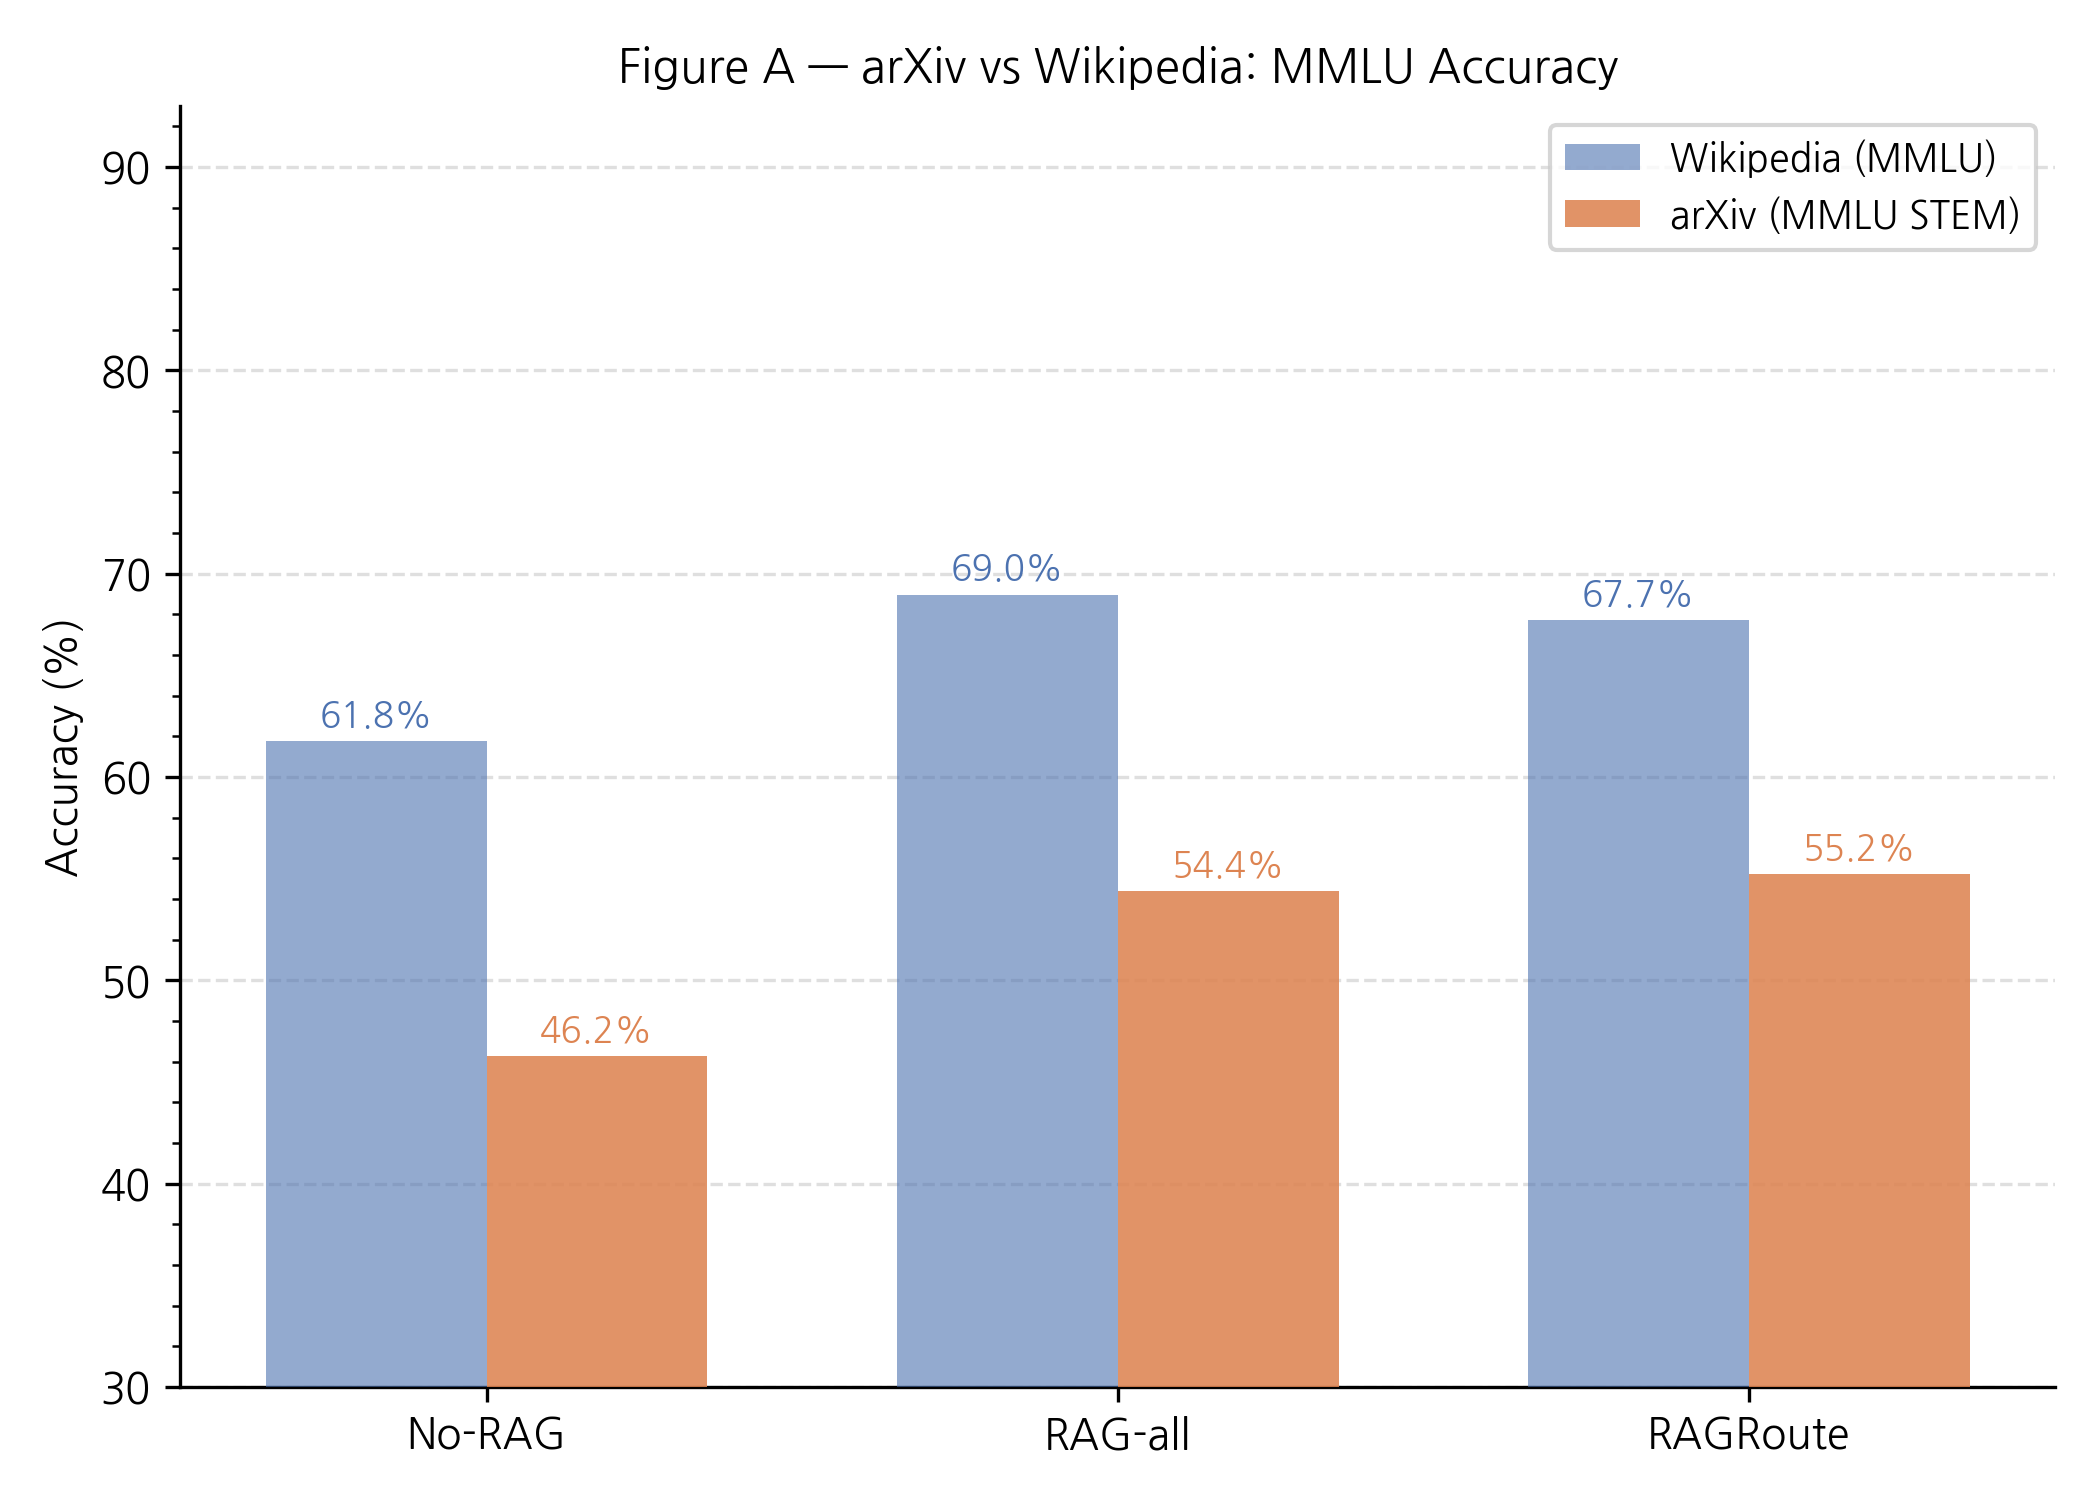

Figure B saved


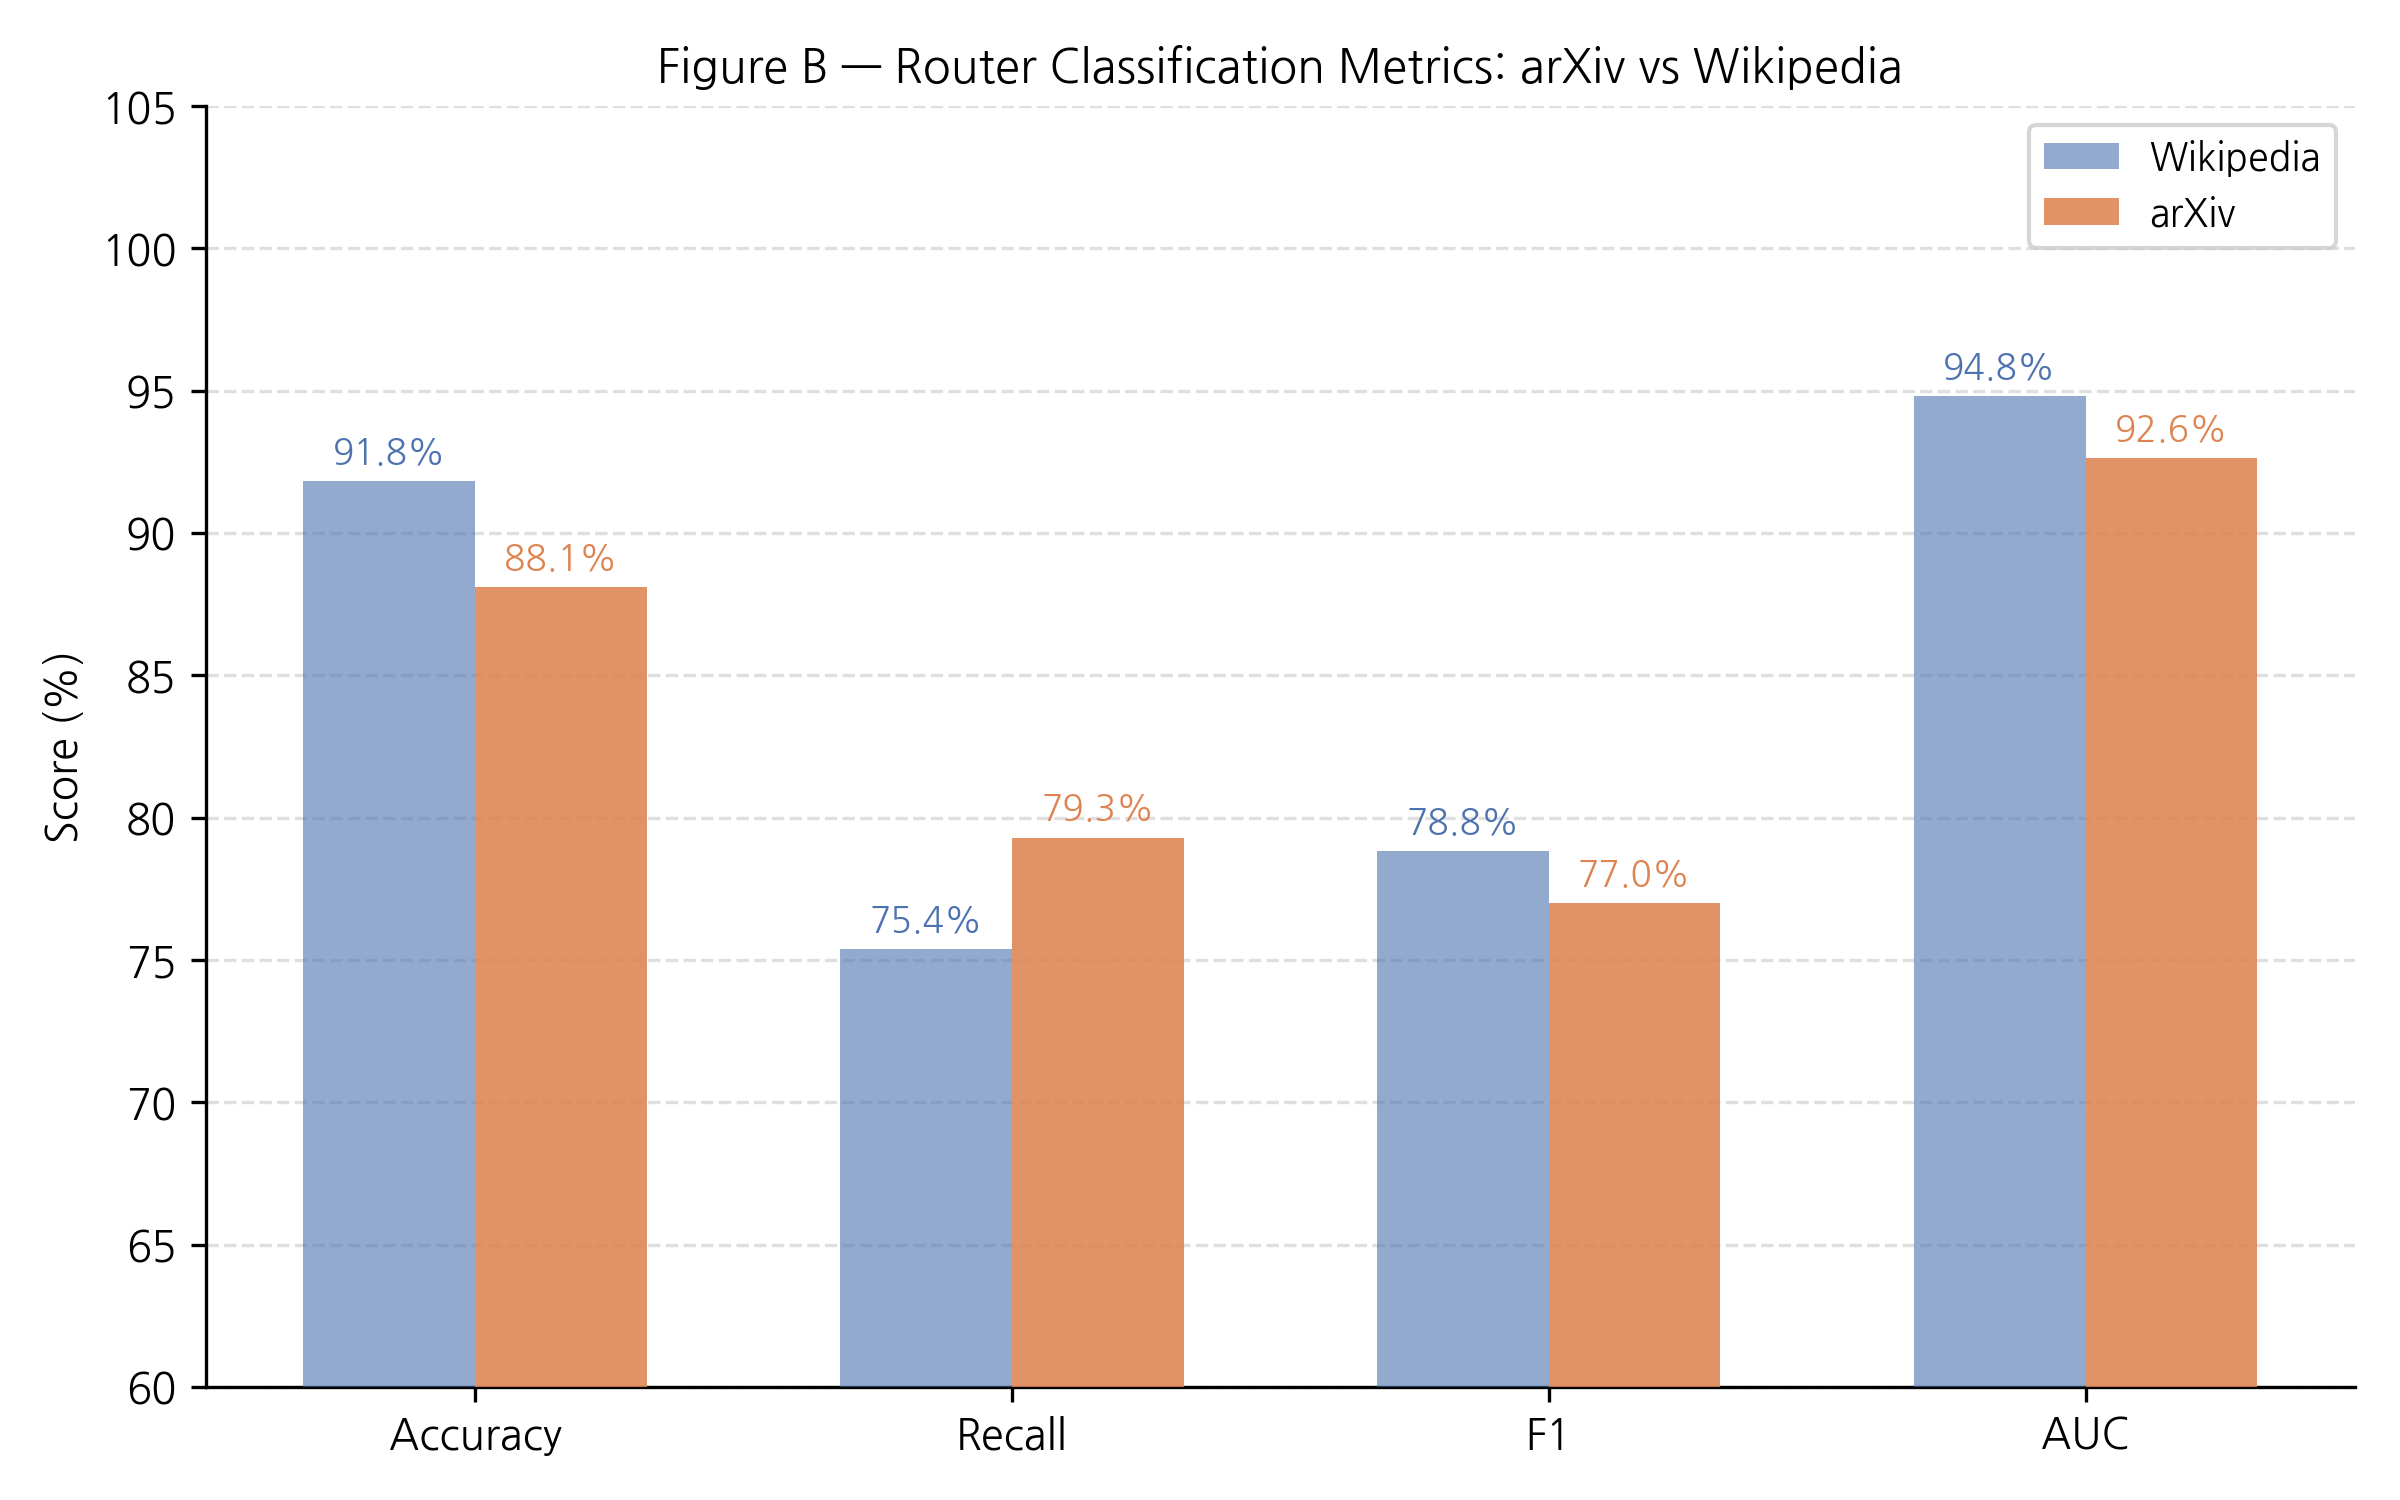

Figure C saved


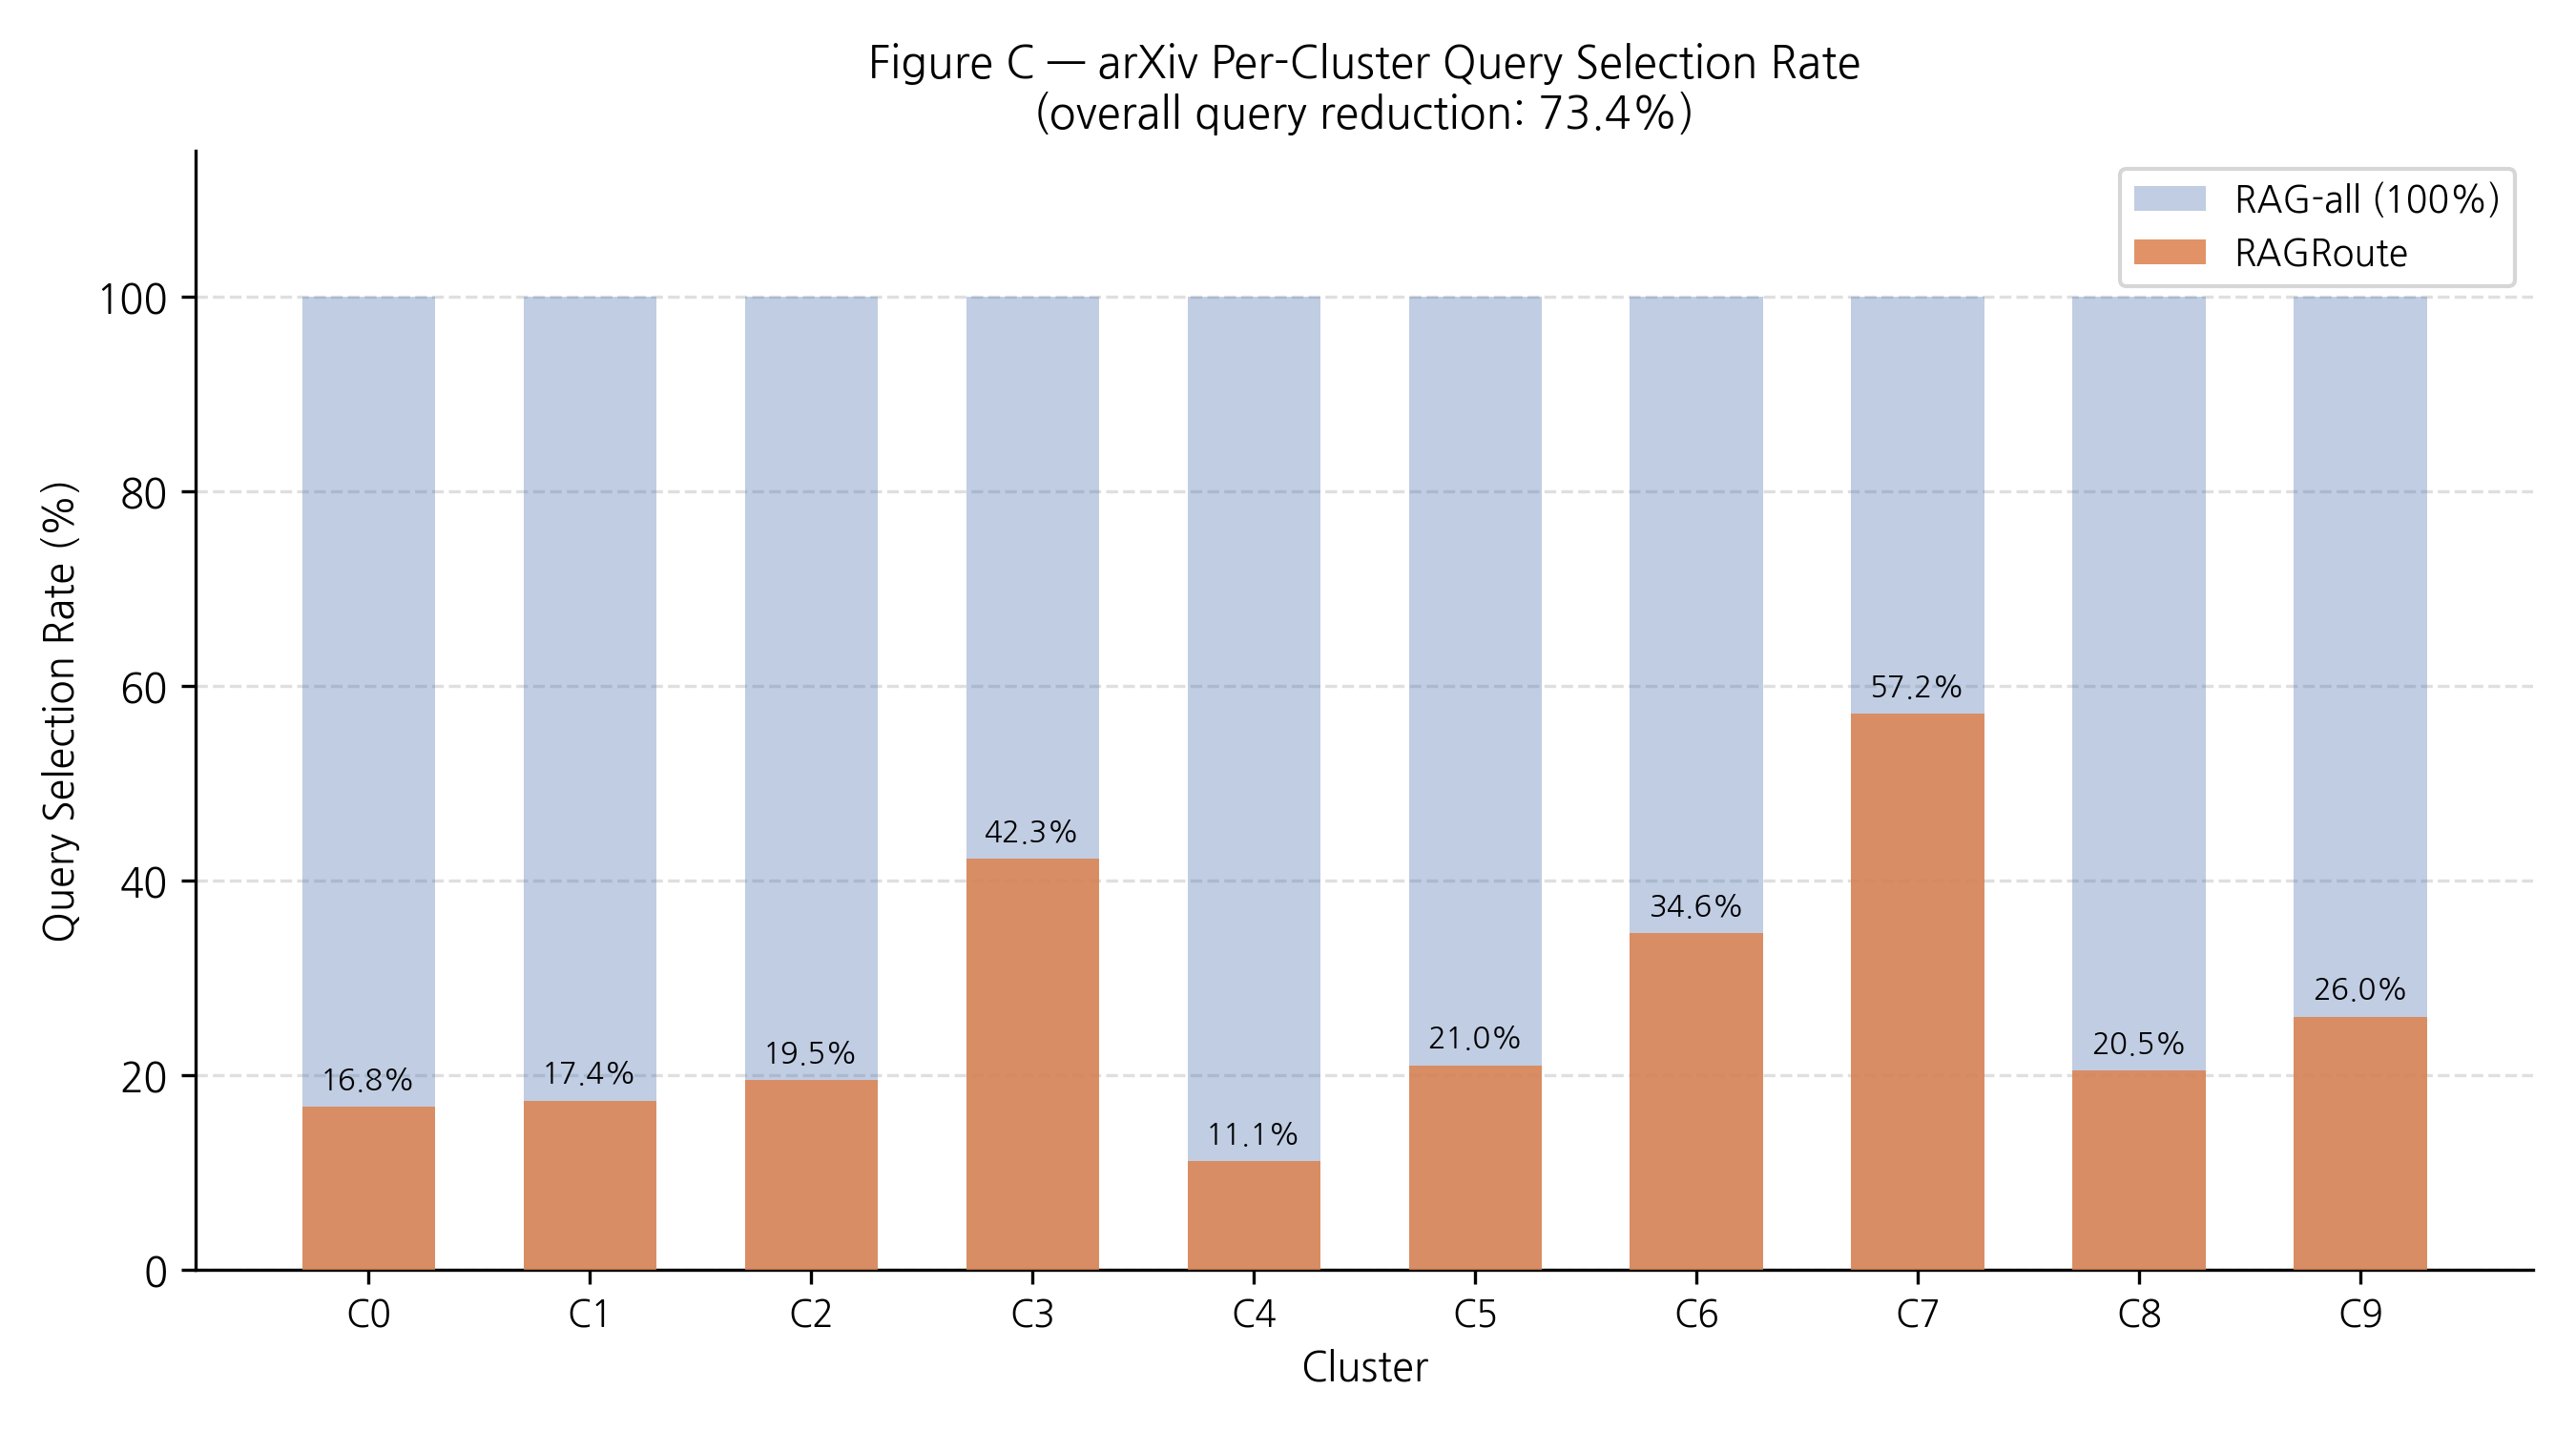

In [ ]:
# 한글 폰트 설치
import subprocess
subprocess.run(['apt-get', 'install', '-y', '-q', 'fonts-nanum'], capture_output=True)
import matplotlib
matplotlib.use('Agg')
import matplotlib.font_manager as fm
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
matplotlib.rcParams['font.family'] = 'NanumGothic'
matplotlib.rcParams['axes.unicode_minus'] = False

import json, os, pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import torch
from IPython.display import Image, display
from sklearn.metrics import accuracy_score, f1_score, recall_score, roc_auc_score
from src.config import INPUT_DIM
from src.router_model import CorpusRoutingNN

os.makedirs('figures', exist_ok=True)

RESULTS_DIR = 'results/arxiv'
MODES       = ['no_rag', 'rag_all', 'ragroute']
MODE_LABELS = {'no_rag': 'No-RAG', 'rag_all': 'RAG-all', 'ragroute': 'RAGRoute'}
MODE_COLORS = {'no_rag': '#6c757d', 'rag_all': '#4c72b0', 'ragroute': '#dd8452'}

# wikipedia 비교 기준 (기존 실험 결과)
WIKI_REF = {'no_rag': 61.77, 'rag_all': 68.97, 'ragroute': 67.72}

def _load(mode):
    p = f'{RESULTS_DIR}/{mode}_arxiv.json'
    return json.load(open(p)) if os.path.exists(p) else None

results = {m: _load(m) for m in MODES}

# ── Figure A: arXiv vs wikipedia 정확도 비교 ─────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
x = np.arange(len(MODES))
width = 0.35

arxiv_vals = [results[m]['accuracy'] if results[m] else 0 for m in MODES]
wiki_vals  = [WIKI_REF[m] for m in MODES]

bars_wiki  = ax.bar(x - width/2, wiki_vals,  width, label='Wikipedia (MMLU)',
                    color='#4c72b0', alpha=0.6, zorder=3)
bars_arxiv = ax.bar(x + width/2, arxiv_vals, width, label='arXiv (MMLU STEM)',
                    color='#dd8452', alpha=0.88, zorder=3)

for bar, val in zip(bars_wiki, wiki_vals):
    ax.text(bar.get_x()+bar.get_width()/2, val+0.4, f'{val:.1f}%',
            ha='center', va='bottom', fontsize=8.5, color='#4c72b0')
for bar, val in zip(bars_arxiv, arxiv_vals):
    if val: ax.text(bar.get_x()+bar.get_width()/2, val+0.4, f'{val:.1f}%',
                    ha='center', va='bottom', fontsize=8.5, color='#dd8452')

ax.set_xticks(x)
ax.set_xticklabels([MODE_LABELS[m] for m in MODES], fontsize=10)
ax.set_ylabel('Accuracy (%)', fontsize=10)
ax.set_title('Figure A — arXiv vs Wikipedia: MMLU Accuracy', fontsize=11, fontweight='bold')
ax.set_ylim(30, 93)
ax.yaxis.set_minor_locator(mticker.MultipleLocator(2))
ax.grid(axis='y', linestyle='--', alpha=0.4, zorder=0)
ax.legend(fontsize=9)
ax.spines[['top','right']].set_visible(False)
fig.tight_layout()
fig.savefig('figures/arxiv_figA_accuracy.png', dpi=300)
plt.close(fig)
print('Figure A saved')
display(Image('figures/arxiv_figA_accuracy.png'))

# ── Figure B: 라우터 분류 성능 ────────────────────────────────────────────
proc_dir = 'data/processed/arxiv'
ckpt     = 'arxiv'
paths_ok = all(os.path.exists(p) for p in [
    f'{proc_dir}/X_test.npy', f'{proc_dir}/y_test.npy',
    f'checkpoints/{ckpt}_model_best.pth', f'checkpoints/{ckpt}_scaler.pkl'
])

if paths_ok:
    X = np.load(f'{proc_dir}/X_test.npy').astype(np.float32)
    y = np.load(f'{proc_dir}/y_test.npy')
    m = CorpusRoutingNN(INPUT_DIM['arxiv'])
    m.load_state_dict(torch.load(f'checkpoints/{ckpt}_model_best.pth',
                                  map_location='cpu', weights_only=True))
    m.eval()
    with open(f'checkpoints/{ckpt}_scaler.pkl','rb') as fh: sc = pickle.load(fh)
    X = sc.transform(X).astype(np.float32)
    with torch.no_grad(): p = torch.sigmoid(m(torch.tensor(X)).squeeze(1)).numpy()
    pred = (p >= 0.5).astype(int)

    metrics_arxiv = [
        accuracy_score(y, pred)*100,
        recall_score(y, pred, zero_division=0)*100,
        f1_score(y, pred, zero_division=0)*100,
        roc_auc_score(y, p)*100 if len(np.unique(y))>1 else float('nan'),
    ]
    # wikipedia 참고값 (기존 실험)
    metrics_wiki = [91.81, 75.37, 78.82, 94.80]
    metric_names = ['Accuracy', 'Recall', 'F1', 'AUC']
    metric_colors = ['#4c72b0','#dd8452','#55a868','#c44e52']

    fig, ax = plt.subplots(figsize=(8, 5))
    x = np.arange(len(metric_names))
    width = 0.32
    bars_w = ax.bar(x - width/2, metrics_wiki,  width, label='Wikipedia', color='#4c72b0', alpha=0.6, zorder=3)
    bars_a = ax.bar(x + width/2, metrics_arxiv, width, label='arXiv',     color='#dd8452', alpha=0.88, zorder=3)

    for bar, val in zip(bars_w, metrics_wiki):
        ax.text(bar.get_x()+bar.get_width()/2, val+0.4, f'{val:.1f}%',
                ha='center', va='bottom', fontsize=8.5, color='#4c72b0')
    for bar, val in zip(bars_a, metrics_arxiv):
        if not np.isnan(val):
            ax.text(bar.get_x()+bar.get_width()/2, val+0.4, f'{val:.1f}%',
                    ha='center', va='bottom', fontsize=8.5, color='#dd8452')

    ax.set_xticks(x)
    ax.set_xticklabels(metric_names, fontsize=10)
    ax.set_ylabel('Score (%)', fontsize=10)
    ax.set_title('Figure B — Router Classification Metrics: arXiv vs Wikipedia', fontsize=11, fontweight='bold')
    ax.set_ylim(60, 105)
    ax.grid(axis='y', linestyle='--', alpha=0.4, zorder=0)
    ax.legend(fontsize=9)
    ax.spines[['top','right']].set_visible(False)
    fig.tight_layout()
    fig.savefig('figures/arxiv_figB_cls_metrics.png', dpi=300)
    plt.close(fig)
    print('Figure B saved')
    display(Image('figures/arxiv_figB_cls_metrics.png'))
else:
    print('Figure B: 체크포인트 없음 — cell-arxiv-train 실행 후 재시도')

# ── Figure C: 클러스터별 쿼리 선택률 (Query Reduction) ───────────────────
ragroute_r = results.get('ragroute')
if ragroute_r and ragroute_r.get('records'):
    cluster_counts = {str(c): 0 for c in range(10)}
    n_total = 0
    for rec in ragroute_r['records']:
        n_total += 1
        for src in rec.get('selected_sources', []):
            if src in cluster_counts:
                cluster_counts[src] += 1

    rates = [cluster_counts[str(c)] / n_total * 100 for c in range(10)]
    overall_reduction = (1 - sum(cluster_counts.values())/(n_total*10)) * 100

    fig, ax = plt.subplots(figsize=(9, 5))
    x = np.arange(10)
    ax.bar(x, [100]*10, 0.6, label='RAG-all (100%)', color='#4c72b0', alpha=0.35, zorder=2)
    bars = ax.bar(x, rates, 0.6, label='RAGRoute', color='#dd8452', alpha=0.88, zorder=3)
    for bar, rate in zip(bars, rates):
        ax.text(bar.get_x()+bar.get_width()/2, rate+1.2, f'{rate:.1f}%',
                ha='center', va='bottom', fontsize=7.5)

    ax.set_xticks(x)
    ax.set_xticklabels([f'C{c}' for c in range(10)], fontsize=9)
    ax.set_xlabel('Cluster', fontsize=10)
    ax.set_ylabel('Query Selection Rate (%)', fontsize=10)
    ax.set_title(
        f'Figure C — arXiv Per-Cluster Query Selection Rate\n'
        f'(overall query reduction: {overall_reduction:.1f}%)',
        fontsize=11, fontweight='bold')
    ax.set_ylim(0, 115)
    ax.grid(axis='y', linestyle='--', alpha=0.4, zorder=0)
    ax.legend(fontsize=9)
    ax.spines[['top','right']].set_visible(False)
    fig.tight_layout()
    fig.savefig('figures/arxiv_figC_query_reduction.png', dpi=300)
    plt.close(fig)
    print('Figure C saved')
    display(Image('figures/arxiv_figC_query_reduction.png'))
else:
    print('Figure C: ragroute 결과 없음 — cell-arxiv-eval 실행 후 재시도')
